In [52]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
!pip install faker
!pip install dash

import pandas as pd
import numpy as np
from faker import Faker
import random
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [37]:
df = pd.read_csv("/content/drive/MyDrive/PROJECT/covid_19_clean_complete.csv")

print(df.head())
print(df.info())

  Province/State Country/Region       Lat       Long        Date  Confirmed  \
0            NaN    Afghanistan  33.93911  67.709953  2020-01-22          0   
1            NaN        Albania  41.15330  20.168300  2020-01-22          0   
2            NaN        Algeria  28.03390   1.659600  2020-01-22          0   
3            NaN        Andorra  42.50630   1.521800  2020-01-22          0   
4            NaN         Angola -11.20270  17.873900  2020-01-22          0   

   Deaths  Recovered  Active             WHO Region  
0       0          0       0  Eastern Mediterranean  
1       0          0       0                 Europe  
2       0          0       0                 Africa  
3       0          0       0                 Europe  
4       0          0       0                 Africa  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0

In [38]:
df = df[['Date', 'Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active']]

In [39]:
df.columns = ['Date', 'Country', 'Confirmed', 'Deaths', 'Recovered', 'Active']

In [40]:
df['Date'] = pd.to_datetime(df['Date'])

In [41]:
print(df.isnull().sum())

Date         0
Country      0
Confirmed    0
Deaths       0
Recovered    0
Active       0
dtype: int64


In [42]:
df.drop_duplicates(inplace=True)

In [43]:
cols = ['Confirmed', 'Deaths', 'Recovered', 'Active']
df[cols] = df[cols].apply(pd.to_numeric)

In [44]:
print("Total Confirmed:", df['Confirmed'].sum())
print("Total Deaths:", df['Deaths'].sum())
print("Total Recovered:", df['Recovered'].sum())

print(df.describe())

Total Confirmed: 828507763
Total Deaths: 43384902
Total Recovered: 388408160
                                Date     Confirmed         Deaths  \
count                          47172  4.717200e+04   47172.000000   
mean   2020-04-27 06:11:54.322055424  1.756355e+04     919.717248   
min              2020-01-22 00:00:00  0.000000e+00       0.000000   
25%              2020-03-13 00:00:00  8.000000e+00       0.000000   
50%              2020-04-28 00:00:00  1.930000e+02       3.000000   
75%              2020-06-12 00:00:00  1.661000e+03      35.000000   
max              2020-07-27 00:00:00  4.290259e+06  148011.000000   
std                              NaN  1.297875e+05    6436.680583   

          Recovered        Active  
count  4.717200e+04  4.717200e+04  
mean   8.233871e+03  8.409961e+03  
min    0.000000e+00 -1.400000e+01  
25%    0.000000e+00  0.000000e+00  
50%    4.400000e+01  3.500000e+01  
75%    7.550000e+02  6.870000e+02  
max    1.846641e+06  2.816444e+06  
std    5.5867

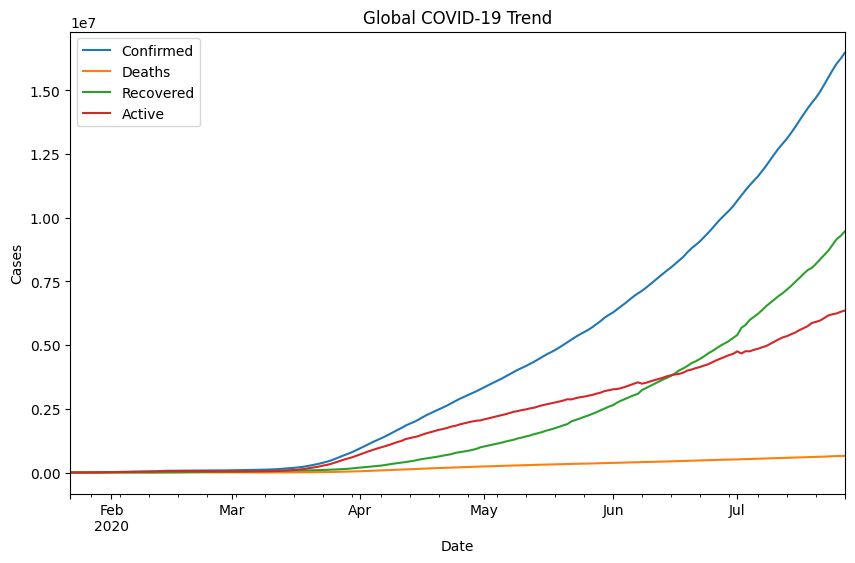

In [45]:
trend = df.groupby('Date')[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum()

trend.plot(figsize=(10,6))
plt.title("Global COVID-19 Trend")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.show()

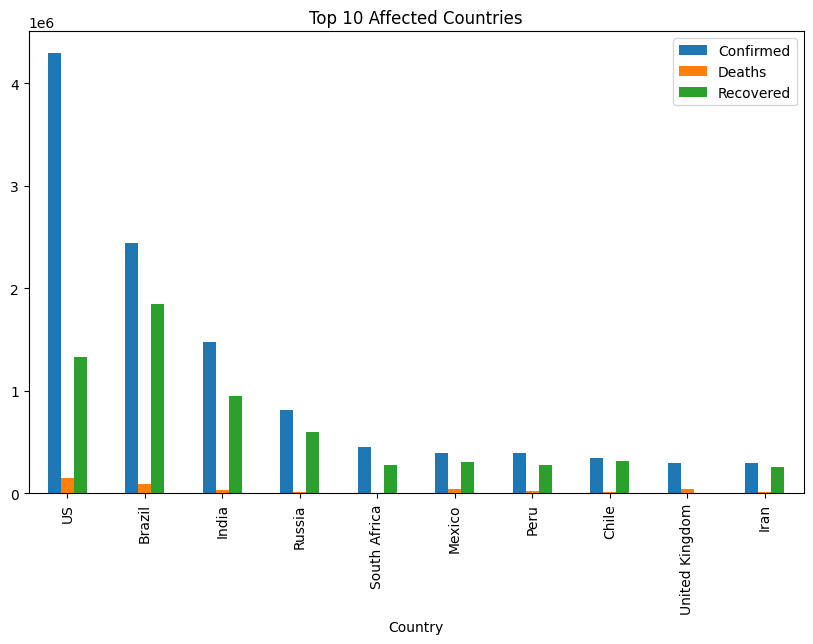

In [46]:
country_data = df.groupby('Country')[['Confirmed', 'Deaths', 'Recovered']].max()

top_countries = country_data.sort_values(by='Confirmed', ascending=False).head(10)

top_countries.plot(kind='bar', figsize=(10,6))
plt.title("Top 10 Affected Countries")
plt.show()

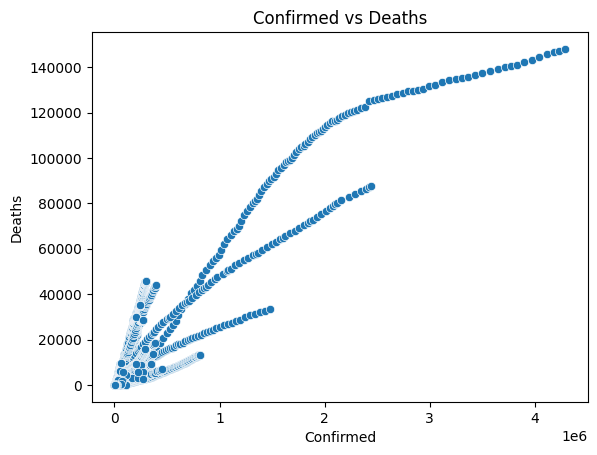

In [47]:
sns.scatterplot(x='Confirmed', y='Deaths', data=df)
plt.title("Confirmed vs Deaths")
plt.show()

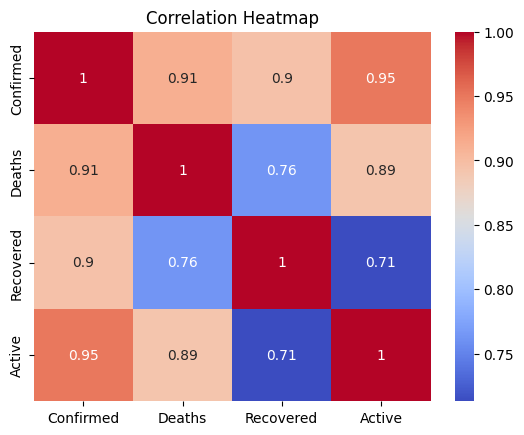

In [48]:
corr = df[['Confirmed','Deaths','Recovered','Active']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

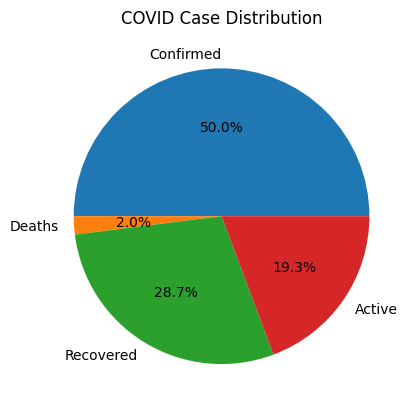

In [49]:
latest = df[df['Date'] == df['Date'].max()]

summary = latest[['Confirmed','Deaths','Recovered','Active']].sum()

plt.pie(summary, labels=summary.index, autopct='%1.1f%%')
plt.title("COVID Case Distribution")
plt.show()

In [50]:
import plotly.express as px
fig = px.line(trend, title="COVID Trend Over Time")
fig.show()

fig = px.bar(top_countries, x=top_countries.index, y='Confirmed',
             title="Top Countries")
fig.show()
fig = px.scatter(df, x='Confirmed', y='Deaths',
                 title="Confirmed vs Deaths")
fig.show()

In [51]:
from dash import Dash, dcc, html, Input, Output
import plotly.express as px

app = Dash(__name__)

countries = df['Country'].unique()

app.layout = html.Div([
    html.H1("COVID-19 Dashboard"),

    dcc.Dropdown(
        id='country-dropdown',
        options=[{'label': c, 'value': c} for c in countries],
        value='India'
    ),

    dcc.DatePickerRange(
        id='date-picker',
        start_date=df['Date'].min(),
        end_date=df['Date'].max()
    ),

    dcc.Graph(id='line-chart')
])

@app.callback(
    Output('line-chart', 'figure'),
    Input('country-dropdown', 'value'),
    Input('date-picker', 'start_date'),
    Input('date-picker', 'end_date')
)
def update_chart(country, start_date, end_date):
    filtered = df[
        (df['Country'] == country) &
        (df['Date'] >= start_date) &
        (df['Date'] <= end_date)
    ]

    trend = filtered.groupby('Date')['Confirmed'].sum().reset_index()

    fig = px.line(trend, x='Date', y='Confirmed',
                  title=f"{country} COVID Trend")
    return fig

if __name__ == '__main__':
    app.run(debug=True)

Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'
 * Debug mode: on
